# DP2 Satellite Analysis

In [1]:
! eups list -s lsst_distrib

   g00e868bf88+63be048ebb 	w_2026_16 w_latest current setup


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
import numpy as np
import json
import time
import requests
import astropy.units as u
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord

from lsst.daf.butler import Butler, DatasetNotFoundError
from lsst.obs.lsst import LsstCam
import lsst.geom as geom

class Glint():
    """Convenience class for trailed glints.
    """

    def __init__(self, visit, detector, slope, intercept):
        self.visit = visit
        self.detector = detector
        self.slope = slope
        self.intercept = intercept

    @classmethod
    def from_dict(cls, visit, detector, glints_dict):
        """Initialize from existing `trailed_glints_info` dictionary definition.
        """
        num_glints = len(glints_dict['slopes'])
        glints = [cls(detector, glints_dict['slopes'][n], glints_dict['intercepts'][n]) for n in range(num_glints)]

        return glints

    @classmethod
    def from_dataframe(cls, glints_df):
        """Initialize from `trailed_glints_visit` dataframe.
        """
        visit = glints_df.meta['visit']
        glints = [cls(visit, int(row['detector']), row['slopes'], row['intercepts']) for row in glints_df]

        return glints

    def calculate_xy_arrays(self, bounds=[0, 4096, 0, 4004], origin=[2047.5, 2001.5], num=1000):
        """Calculate detector x/y points corresponding to glint.
        """
        left, right, bottom, top = bounds
        x = np.linspace(left, right, num, endpoint=False)
        y = self.slope*x + self.intercept

        # Filter for points within detector bounds
        indices = (y >= bottom)*(y < top)
        x = x[indices]
        y = y[indices]

        return x, y

    def calculate_radec_arrays(self, wcs, num=1000):

        xs, ys = self.calculate_xy_arrays(num=num)
        det_points = [geom.Point2D(x, y) for x, y in zip(xs, ys)]
        sky_points = wcs.pixelToSky(det_points)
    
        ras = [sp.getRa().asDegrees() for sp in sky_points]
        decs = [sp.getDec().asDegrees() for sp in sky_points]

        return ras, decs

class Streak():
    """Convenience class for masked streaks.
    """

    def __init__(self, visit, detector, rho, theta):
        self.visit = visit
        self.detector = detector
        self.rho = rho # pixels
        self.theta = theta # degrees

    @classmethod
    def from_dataframe(cls, streaks_df):
        """Initialize from `trailed_glints_visit` dataframe.
        """
        visit = streaks_df.meta['visit']
        streaks = [cls(visit, int(row['detector']), row['rho'], row['theta']) for row in streaks_df]

        return streaks

    def calculate_xy_arrays(self, bounds=[0, 4096, 0, 4004], origin=[2047.5, 2001.5], num=1000):
        """Calculate detector x/y points corresponding to streak.
        """
        # Transform to new origin = (0, 0)
        xc, yc = origin
        theta = np.deg2rad(self.theta) # must be in radians
        rho = self.rho + xc*np.cos(theta) + yc*np.sin(theta)
    
        left, right, bottom, top = bounds
        x = np.linspace(left, right, num, endpoint=False)
    
        if np.isclose(np.sin(theta), 0, atol=1.E-6):
            x.fill(rho/np.cos(theta))
            y = np.linspace(bottom, top, num, endpoint=False)
        else:
            y = (rho - x*np.cos(theta))/np.sin(theta)
            indices = (y >= bottom)*(y < top)
            x = x[indices]
            y = y[indices]
    
        return x, y

    def calculate_radec_arrays(self, wcs, num=1000):

        xs, ys = self.calculate_xy_arrays(num=num)
        det_points = [geom.Point2D(x, y) for x, y in zip(xs, ys)]
        sky_points = wcs.pixelToSky(det_points)
    
        ras = [sp.getRa().asDegrees() for sp in sky_points]
        decs = [sp.getDec().asDegrees() for sp in sky_points]

        return ras, decs

In [3]:
# Define Butler for satellite analysis
repo = '/sdf/group/rubin/repo/dp2_prep'
camera = LsstCam().getCamera()
instrument = camera.getName()
collections = 'u/snyder18/DRP/20250515-20251214/satelliteAnalysis'

butler = Butler(repo, collections=collections, instrument=instrument)

In [4]:
# Get datasets corresponding to a visit
visit = 2025071700631
trailed_glints_visit = butler.get('trailed_glints_visit', visit=visit)
difference_streaks_visit = butler.get('difference_streaks_visit', visit=visit)
pvs = butler.get('preliminary_visit_summary', visit=visit)

streaks = Streak.from_dataframe(difference_streaks_visit)
glints = Glint.from_dataframe(trailed_glints_visit)
print(len(streaks), len(glints))

10 10


In [5]:
try:
    with open(f"fov_satellites_{visit}.json", 'r') as f:
        data = json.load(f)
except FileNotFoundError:
    BASE_URL = 'https://satchecker.cps.iau.org'
    # Get API parameters
    visit_info = pvs[0].getVisitInfo()
    mid_obs_time_jd = visit_info.date.get(visit_info.date.DateSystem.JD)
    print(mid_obs_time_jd)
    center = visit_info.boresightRaDec
    ra_center = center.getRa().asDegrees()
    dec_center = center.getDec().asDegrees()
    
    params = {'site' : 'lsst',
              'mid_obs_time_jd' : mid_obs_time_jd,
              'duration' : 60.0,
              'ra' :ra_center,
              'dec' : dec_center,
              'fov_radius' : 3.0,
              'group_by': 'satellite',
              'async' : True}
    
    # Step 1: Submit API request
    response = requests.get(f"{BASE_URL}/fov/satellite-passes/", params=params, timeout=120)
    response.raise_for_status()
    task_id = response.json()["task_id"]
    print(json.dumps(response.json(), indent=4))
    
    # Step 2: Poll for results
    while True:
        status_response = requests.get(
            f"{BASE_URL}/fov/task-status/{task_id}", timeout=30
        )
        status_response.raise_for_status()
        status_data = status_response.json()
    
        status = status_data["status"]

        if status == "SUCCESS":
            print("Task completed!")
            data = status_data.get('data', {})
            print(f"Found {data.get('total_satellites', 0)} satellites")
            print(f"Total position results: {data.get('total_position_results', 0)}")
            break
        elif status == "FAILURE":
            print(f"Task failed: {status_data.get('error')}")
            break
        elif status == "PROGRESS":
            progress = status_data.get("progress", 0)
            print(f"Progress: {progress:.1f}%")
    
        time.sleep(2)
    
    # Step 3: Save results
    with open(f"fov_satellites_{visit}.json", 'w') as f:
        json.dump(data, f, indent=4)

In [6]:
# Extract RA/Dec positions for each satellite
satellites = {}

for sat_key, sat_data in data['satellites'].items():
    if sat_key not in satellites:
        satellites[sat_key] = []
    # Add ra, dec, and julian_date from each position
    for position in sat_data['positions']:
        satellites[sat_key].append([
            position['ra'],
            position['dec'],
            position['julian_date']
        ])

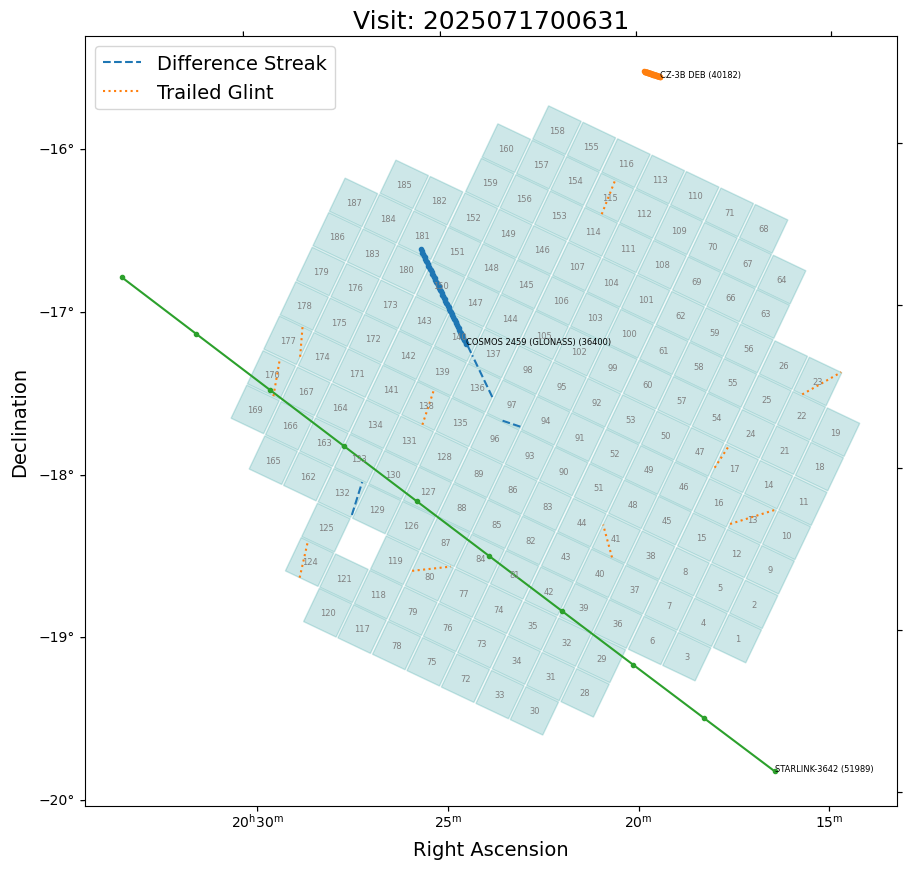

In [7]:
# Dummy WCS using a detector corner.
wcs = WCS(naxis=2)
wcs.wcs.crval = [pvs[0]['raCorners'][0], pvs[0]['decCorners'][0]]      # reference RA, Dec in degrees
wcs.wcs.crpix = [0, 0]      # reference pixel coordinates
wcs.wcs.cdelt = [0.1, 0.1]      # scale: 1 deg/pixel
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]

fig, ax = plt.subplots(1, 1, figsize=(14, 10), facecolor='white', subplot_kw={'projection' : wcs})

# Plot all streaks
for streak in streaks:
    rec = pvs.find(streak.detector)
    ras, decs = streak.calculate_radec_arrays(rec.getWcs(), num=2000)
    if len(ras) == 0: continue
    ax.plot(ras, decs, transform=ax.get_transform("world"), c='C0', linestyle='--')

# Plot all glint trails
for glint in glints:
    rec = pvs.find(glint.detector)
    ras, decs = glint.calculate_radec_arrays(rec.getWcs())
    if len(ras) == 0: continue
    ax.plot(ras, decs, transform=ax.get_transform("world"), c='C1', linestyle=':')

# Satellite tracks
for sat_name in satellites.keys():
    ra = [pos[0] for pos in satellites[sat_name]]
    dec = [pos[1] for pos in satellites[sat_name]]
    coords = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
    
    # Satellite track
    ax.plot(coords.ra.deg, coords.dec.deg, marker='o', markersize=3,
            transform=ax.get_transform('world'), label=sat_name)

    if coords.ra.deg[0] < coords.ra.deg[-1]:
        ax.text(coords.ra.deg[0], coords.dec.deg[0], f'{sat_name}', 
                transform=ax.get_transform('world'), fontsize="6")
    else:
        ax.text(coords.ra.deg[-1], coords.dec.deg[-1], f'{sat_name}', 
            transform=ax.get_transform('world'), fontsize="6")

# Plot all detector boxes with label
for rec in pvs:
    corners = np.column_stack((rec['raCorners'], rec['decCorners']))
    poly = Polygon(corners, closed=True, color="#058B8C", alpha=0.2, transform=ax.get_transform("world"))
    ax.add_patch(poly)

    center_ra = corners[:, 0].mean()
    center_dec = corners[:, 1].mean()
    ax.text(center_ra, center_dec, rec['id'], ha='center', va='center',
            transform=ax.get_transform("world"), fontsize=6, color='grey')

# Make legend
streak_line = Line2D([0], [0], color='C0', linestyle='--')
glint_line = Line2D([0], [0], color='C1', linestyle=':')
ax.legend([streak_line, glint_line], ['Difference Streak', 'Trailed Glint'],
          fontsize=14)

# Plot formatting
ax.set_aspect('equal')
ax.set_xlabel("Right Ascension", fontsize=14)
ax.set_ylabel("Declination", fontsize=14)
ax.set_title(f"Visit: {visit}", fontsize=18)
ax.invert_xaxis()  # Astronomical convention
plt.savefig(f'detected_orbital_objects_{visit}.png')

In [8]:
# Get a detector datasets
detector = 113
pvi = butler.get('preliminary_visit_image', visit=visit, detector=detector)
diffim = butler.get('difference_image', visit=visit, detector=detector)

# Plot image
#fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor='white')
#im = ax.imshow(pvi.getImage().getArray(), origin='lower', vmax=2000.)
#cbar = fig.colorbar(im)
#ax.set_title(f"Visit: {visit}, Detector: {detector}", fontsize=18)
#plt.savefig(f'pvi_{visit}_{detector}.png')